 # Figures of the CMB-S4 $\mathbf{N}_\mathbf{eff}$ Forecasting Paper

All figures of arXiv:26XX.XXXXX.

## Preliminaries

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import healpy as hp
from scipy.ndimage import zoom as sp_zoom

import subprocess

In [2]:
plt.style.use('data/mine.mplstyle')
GOLDEN_RATIO = (1+np.sqrt(5.))/2.

## Underlying Data

### Data

In [3]:
# all_data = {}

In [4]:
# # Figure 1: Thermal relics
# data = '/media/benjamin/data/work/projects/snowmass-whitePapers/lightRelics/myContribution/figures/data/'
# DATA = np.load(data + 'data_neff_standard.npy', allow_pickle=True).item()
# DATA3 = np.load(data + 'data_neff_standard_interp.npy', allow_pickle=True).item()

# a = interpolate(DATA3['logT'][::-1],
#             1.-DATA3['Delta Neff (interpolated)'][::-1]/DATA['Delta Neff (scalar)'][::-1], k=3, s=0)
# transition = a.roots()[a.roots()>0.01][0]

# temp = DATA['logT']
# deltaNeff_new = np.concatenate((DATA3['Delta Neff (interpolated)'][DATA3['logT']>transition],
#                                 DATA['Delta Neff (scalar)'][DATA['logT']<transition]))

# DATA_thermal = {'temp': temp, 'Delta Neff (interpolated)': DATA3['Delta Neff (interpolated)'],
#                 'Delta Neff (combined)': deltaNeff_new, 'particle masses': DATA['particle masses']}
# np.save('data/delta-neff_thermal-relics', DATA_thermal)


# FIGURE1 = np.load('data/delta-neff_thermal-relics.npy', allow_pickle=True).item()

# # 95% c.l. on Delta Neff
# CONSTRAINTS = {'Current': 2*0.12, #\sigma(\Neff) from Planck + ACT + SPT, arXiv:2506.20707
#                'S4': 2*0.03,      # S4 science target
#                'SVL': 2*0.0095,   # Sample-variance-limited survey over 60\% of the sky with maximum multipole 5000
#                'CVL': 2*0.0074    # Cosmic-variance-limited survey (100\% of the sky) with maximum multipole 5000
#               }
# FIGURE1['Constraints (2sigma)'] = CONSTRAINTS

In [5]:
# # Figure 2
# def healpix_rotate_coords(hmap, coord, beam_to_use_for_smoothing = None, threshold = 0.001):
#     """
#     coord = ['C', 'G'] to convert a map in RADEC to Gal.    
#     """

#     #get map pixel
#     pixel = np.arange(len(hmap))

#     #get angles in this map first
#     nside = hp.get_nside(hmap)
#     angles = hp.pix2ang(nside, pixel)

#     #rotate the angles to the desired new coordinate
#     rotated_angles = hp.Rotator(coord=coord)(*angles)

#     #get the rotated pixel values
#     rotated_pixel = hp.ang2pix(nside, *rotated_angles)

#     #initialise new map
#     rot_hmap = np.zeros(len(pixel))

#     #push the original map pixel to the new map (in the rotated pixel positions)
#     rot_hmap[rotated_pixel] = hmap[pixel]
#     if beam_to_use_for_smoothing is not None:
#         rot_hmap = hp.smoothing(rot_hmap, fwhm = np.radians(beam_to_use_for_smoothing))
#         rot_hmap[rot_hmap>threshold] = 1.
#         rot_hmap[rot_hmap<threshold] = 0.

#     return rot_hmap

# gal_mask = hp.read_map('github_srini/data/HFI_Mask_GalPlane-apo0_512_R2.00.fits', field = (5))
# gal_mask = healpix_rotate_coords(gal_mask, ['G', 'C'], beam_to_use_for_smoothing=1.)

# dust_map = hp.read_map('github_srini/data/COM_CompMap_dust-commander_0256_R2.00.fits')

# opfname = 'github_srini/data/hmap_patches_noisemap_dictionary.npy'
# hmap_patches_noisemap_dic = np.load(opfname, allow_pickle=True).item()

# splat = hmap_patches_noisemap_dic['splat_dc0']
# splat[splat>0.4] = hp.UNSEEN # SPTLAT - Only have the deepest patch
# nside_deep = hp.npix2nside(len(splat))
# valid_mask = (splat != hp.UNSEEN) & (gal_mask != 0)
# boundary_pix = []
# for px in np.where(valid_mask)[0]:
#     neighbours = hp.get_all_neighbours(nside_deep, px)
#     neighbours = neighbours[neighbours >= 0]  # remove -1 (missing neighbours at poles)
#     if np.any(~valid_mask[neighbours]):
#         boundary_pix.append(px)
# boundary_pix = np.array(boundary_pix)
# theta, phi = hp.pix2ang(nside_deep, boundary_pix)
# splat_ra_boundary  = np.degrees(phi)
# splat_dec_boundary = 90. - np.degrees(theta)

# FIGURE2 = {'dust map': dust_map, 
#            'pbd footprint': {'wide': {'RA': [-180, 180], 'DEC': [-62, 25]},
#                              'ultra-deep': {'RA': splat_ra_boundary, 'DEC': splat_dec_boundary}},
#            'revised footprint': {'wide': hmap_patches_noisemap_dic['lat_wide'],
#                                  'delensing': hmap_patches_noisemap_dic['lat_delensing'],
#                                  'galactic mask': gal_mask},
#            'info': {'galactic mask': 'HFI_Mask_GalPlane-apo0_512_R2.00.fits, field=(5), rotated coordinates to galactic',
#                     'dust map': 'COM_CompMap_dust-commander_0256_R2.00.fits',
#                     'pbd footprint': 'Right ascension and declination',
#                     'revised footprint': ['Four patches each for the Hybrid Wide and Hybrid Delensing surveys '
#                                           + 'of the revised configuration; additionally the Planck galactic mask '
#                                           + "'HFI_Mask_GalPlane-apo0_512_R2.00.fits' with field=(5) and coordinates"
#                                           + 'rotated to galactic'][0]
#                    }
#           }

# np.save('data/footprints.npy', FIGURE2)

In [6]:
# # Figure 3
# DATA = np.load('github_srini/data/cmbs4_nl_and_fgcl_dict.npy', allow_pickle=True).item()
# SPECTRA = np.load('data/spectra_class_fiducial_tetralith.npy', allow_pickle=True).item()
# #SPECTRA = np.transpose(np.loadtxt('data/output_planck_r_0.0_2015_cosmo_lensedCls.dat'))

# FIGURE3 = {}
# for num, spec in enumerate(['TT', 'EE']):
#     FIGURE3[spec] = {}
#     for typ in ['cmb', 'noise', 'galdust', 'galsync', 'radio', 'tsz', 'ksz', 'cib']:
#         FIGURE3[spec][typ] = {}
#         nu_arr_to_plot = np.unique([nu1 for (nu1, nu2) in list(DATA['fg_cl_dic'][spec][typ].keys())])
#         nu_mapping_dict = {27: 25, 39: 40, 93: 90, 145: 150, 225: 230, 278: 280}
#         for nu in nu_arr_to_plot:
#             if typ == 'cmb':
#                 FIGURE3[spec][typ][nu_mapping_dict[nu]] = 2.7255e6**2 * SPECTRA[f'cl{spec}lensed'][:6001]
#             else:
#                 FIGURE3[spec][typ][nu_mapping_dict[nu]] = DATA['fg_cl_dic'][spec][typ][(nu, nu)][:6001]
# np.save('data/foregrounds.npy', FIGURE3)

In [7]:
# # Figure 4
# SPECTRA = np.load('data/spectra_class_fiducial_tetralith.npy', allow_pickle=True).item()
# #SPECTRA = np.transpose(np.loadtxt('data/output_planck_r_0.0_2015_cosmo_lensedCls.dat'))
# #SPECTRA = {'clTTlensed': np.append([0,0],SPECTRA[1])/2.7255e6**2, 'clEElensed': np.append([0,0],SPECTRA[3])/2.7255e6**2}
# DATA = {'wide': np.load('data/s4wide_202310xx_pbdr_config_ilc_galaxy1_27-39-93-145-225-278_TT-EE_galmask2_AZ_lmax6500_for7years.npy',
#                         allow_pickle=True).item(),
#         'deep': np.load('data/s4deepv3r025_202310xx_pbdr_config_ilc_galaxy0_20-27-39-93-145-225-278_TT-EE_lmax6500_for7years.npy',
#                         allow_pickle=True).item()}
        
# def noise_spec(el, beamwidth, Delta, el_knee, alpha_knee):
#     arcmin_fac = np.pi/(60*180)
#     exponent = el*(el+1) * (beamwidth * arcmin_fac)**2 / (8 * np.log(2))
#     if 0 in np.asarray(el):
#         atmosphere = np.array([1 + (l/el_knee)**(-alpha_knee) if l != 0 else 0 for l in np.asarray(el)])
#     return (Delta * arcmin_fac)**2 * np.exp(exponent) * atmosphere

# num = 0
# FIGURE4 = {}
# for spec in ['TT', 'EE']:
#     FIGURE4[spec] = {}
#     tp = 'T' if spec == 'TT' else 'P'
#     for survey in ['wide', 'deep']:
#         FIGURE4[spec][survey] = {}
#         FIGURE4[spec][survey]['ell'] = DATA[survey]['el'][:6001]
#         FIGURE4[spec][survey]['cmb'] = 2.7255e6**2 * SPECTRA[f'cl{spec}lensed'][:6001]
#         FIGURE4[spec][survey]['ilc'] = DATA[survey]['cl_residual'][spec][:6001]
#         for nu in DATA[survey]['beam_noise_dic'][tp]:
#             nu_mapping_dict = {20: 20, 27: 25, 39: 40, 93: 90, 145: 150, 225: 230, 278: 280}
#             noise_spectrum = noise_spec(DATA[survey]['el'][:6001], DATA[survey]['beam_noise_dic'][tp][nu][0],
#                                         DATA[survey]['beam_noise_dic'][tp][nu][1], DATA[survey]['elknee_dic'][tp][nu][0],
#                                         DATA[survey]['elknee_dic'][tp][nu][1])
#             FIGURE4[spec][survey][f'nl_{nu_mapping_dict[nu]}'] = noise_spectrum
# np.save('data/internal-linear-combination.npy', FIGURE4)

In [8]:
# # # Figure 5: Neff as function of time
# pldict = np.load('github_srini/results/neff/consolidated_s4_allchile_config_results.npy', allow_pickle=True).item()
# DATA_S4_REVISED = {'Calendar year': np.insert(pldict['aso_opt+final'][0], 4, pldict['aso_opt'][0][4]), #Inserting 2033 from ASO-Goal
#                    'sigma_neff':  np.insert(pldict['aso_opt+final'][1], 4, pldict['aso_opt'][1][4]), #Inserting 2033 from ASO-Goal
#                    'info': 'ASO-Goal + CMB-S4, with ASO and CMB-S4 starting in 2028 and 2033, respectively'}
# DATA_S4_REVISED['years'] = DATA_S4_REVISED['Calendar year'] - 2033
# del DATA_S4_REVISED['Calendar year']
# np.save('data/sigma-neff_s4-revised_time.npy', DATA_S4_REVISED)


# DATA_S4_POLE = {'years': np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20]),
#                 'sigma_neff': np.array([0.0570, 0.0525, 0.0503, 0.0488, 0.0478, 0.0469, 0.0463, 0.0457, 0.0453, 0.0449,
#                                         0.0442, 0.0437, 0.0433, 0.0429, 0.0426])}
# # FIGURE5_pole_alternative = {'years': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20],
# #                             'fsky':  [0.05, 0.08, 0.11, 0.15, 0.20, 0.25],
# #                             'sigma_neff_0.05': [0.0850, 0.0786, 0.0753, 0.0732, 0.0716, 0.0704, 0.0694, 0.0686, 0.0679, 0.0673,
# #                                                 0.0662, 0.0654, 0.0647, 0.0641, 0.0636],
# #                             'sigma_neff_0.08': [0.0701, 0.0649, 0.0622, 0.0604, 0.0591, 0.0581, 0.0573, 0.0566, 0.0560, 0.0555,
# #                                                 0.0546, 0.0539, 0.0533, 0.0528, 0.0524],
# #                             'sigma_neff_0.11': [0.0570, 0.0525, 0.0503, 0.0488, 0.0478, 0.0469, 0.0463, 0.0457, 0.0453, 0.0449,
# #                                                 0.0442, 0.0437, 0.0433, 0.0429, 0.0426],
# #                             'sigma_neff_0.15': [0.0511, 0.0474, 0.0454, 0.0440, 0.0431, 0.0423, 0.0417, 0.0411, 0.0407, 0.0403,
# #                                                 0.0397, 0.0391, 0.0387, 0.0383, 0.0380],
# #                             'sigma_neff_0.20': [0.0419, 0.0387, 0.0371, 0.0360, 0.0352, 0.0346, 0.0342, 0.0338, 0.0334, 0.0331,
# #                                                 0.0327, 0.0323, 0.0320, 0.0317, 0.0314],
# #                             'sigma_neff_0.25': [0.0407, 0.0375, 0.0359, 0.0348, 0.0340, 0.0333, 0.0328, 0.0324, 0.0320, 0.0317,
# #                                                 0.0312, 0.0307, 0.0304, 0.0301, 0.0298]
# #                            }
# np.save('data/sigma-neff_s4-pole_time.npy', DATA_S4_POLE)


# FIGURE5 = {'s4-pbd': np.load('data/sigma-neff_s4-pbd_time.npy', allow_pickle=True).item(),
#            's4-pole': np.load('data/sigma-neff_s4-pole_time.npy', allow_pickle=True).item(),
#            's4-revised': np.load('data/sigma-neff_s4-revised_time.npy', allow_pickle=True).item()}

In [9]:
# # Figure 6: Survey design
# from misc import elizaTools_new as et_new

# jobNamePlanck = "misc/s4contourplot/fisher_Planck_lmaxTT3000"
# jobNameS4 = "misc/s4contourplot/fisher_s4_lmaxTT3000"
# #print('Forecasts dated 2021-11-05')
# #baoFile8p = "misc/s4contourplot/BAO_DESI_BBN_8p.txt"

# nExps = 20
# sTypes = ["unlensed", "lensed", "delensed"]
# gTypes = ["Gaussian", "nonGaussian"]
# noiseRange = np.arange(0.1, 2.1, 0.1)
# fskyRange = np.arange(0.1, 1.1, 0.05)


# fishersPlanck = et_new.loadGaussianNG(jobName = jobNamePlanck, pythonFlag = 3, returnCosmoParams = False)
# fishersS4, cosmoParams = et_new.loadGaussianNG(jobName = jobNameS4, pythonFlag = 3, returnCosmoParams = True)

# nNoises = len(noiseRange)
# nSkies = len(fskyRange)

# NeffSigmas = np.zeros((nNoises,nSkies))
# NeffIndex = cosmoParams.index('N_eff')
# mnuIndex = cosmoParams.index('mnu')

# gaussToUse = 'Gaussian'
# spectToUse = 'delensed'



# NeffSigmas = np.zeros((nNoises, nSkies))
# NeffIndex = cosmoParams.index('N_eff')

# # fisherS4(f) + fisherPl(0.6-f) + tau -> invert -> sqrt
# totalFishers = dict()
# for i in range(0,nSkies):
#     fishersS4Sky = et_new.addfsky(fishersS4, fskyRange[i])
#     fishersPlanckSky = et_new.addfsky(fishersPlanck, min(0.6-fskyRange[i],0))
#     fishersS4Tau = et_new.addTau(fishersS4Sky, cosmoParams)
#     totalFishers[i] = et_new.addPlanckFisher(fishersS4Tau, fishersPlanckSky)
# for i in range(0,nNoises):
#     for j in range (0,nSkies):
#         sigmaMat = et_new.invertFishers(totalFishers[j])[gaussToUse][spectToUse][i]
#         NeffSigmas[i][j] = np.sqrt(sigmaMat[NeffIndex][NeffIndex])



# # totalFishers from above but fixing mnu
# NeffSigmasFixMnu = np.zeros((nNoises,nSkies))
# paramsToFix = ['mnu']

# for i in range(0,nNoises):
#     for j in range (0,nSkies):
#         fisherMat, cosmoParamsFixMnu = (et_new.fixParametersInFisher(totalFishers[j][gaussToUse]\
#                                                                      [spectToUse][i],
#                                              cosmoParams = cosmoParams,
#                                              paramsToFix = paramsToFix,
#                                              returnFixedParamList = True))
#         NeffIndexFixMnu = cosmoParamsFixMnu.index('N_eff')
#         sigmaMat = et_new.invertFisher(fisherMat)
#         NeffSigmasFixMnu[i][j] = np.sqrt(sigmaMat[NeffIndexFixMnu][NeffIndexFixMnu])

# #np.min(NeffSigmasFixMnu), np.max(NeffSigmasFixMnu)


# noiseRange, fskyRange, NeffSigmasFixMnu

# DATA_design = {'noise_range': noiseRange, 'fsky_range': fskyRange, 'sigma_neff': NeffSigmasFixMnu,
#                'info': ["'sigma_neff' contains the forecasted one-sigma uncertainty for Neff with fixed neutrino masses"
#                         + "based on Fisher matrices with Gaussian covariance and delensed spectra"][0]} # run on 2021-11-05
# np.save('data/sigma-neff_survey-design', DATA_design)

# FIGURE6 = np.load('data/sigma-neff_survey-design.npy', allow_pickle=True).item()

In [10]:
# # Figure 7
# FIGURE7 = {'s4': np.load('data/sigma-neff_s4-pbd_ellmax.npy', allow_pickle=True).item(),
#            'cvl': np.load('data/sigma-neff_cvl_ellmax.npy', allow_pickle=True).item()}
# all_data['Figure 7'] = FIGURE7
# np.save('data/figure_data', all_data)

In [11]:
# all_data = {'Figure 1': FIGURE1, 'Figure 2': FIGURE2, 'Figure 3': FIGURE3, 'Figure 4': FIGURE4,
#             'Figure 5': FIGURE5, 'Figure 6': FIGURE6, 'Figure 7': FIGURE7}
# np.save('data/figure_data', all_data)

In [12]:
all_data = np.load('data/figure_data.npy', allow_pickle=True).item()

## Figures

### Figure 1: Thermal Light Relic Contribution to $\mathbf{N}_\mathbf{eff}$

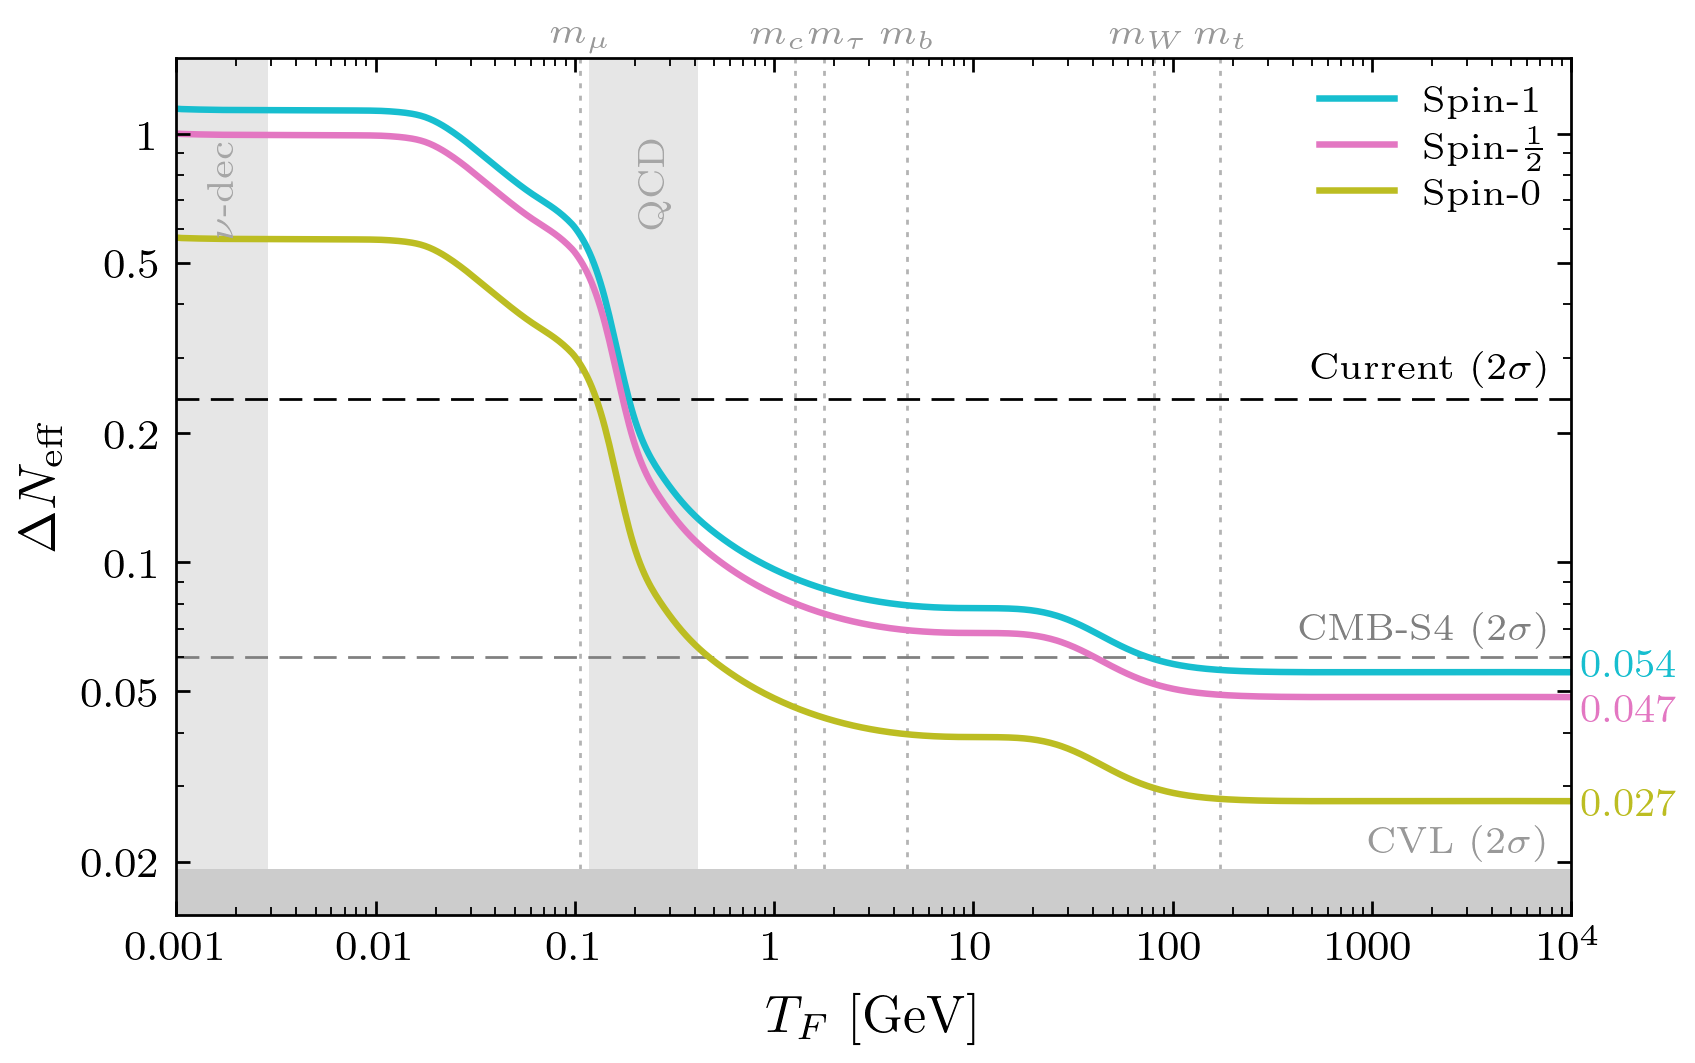

In [13]:
SHORT_DASHES = (1.8, 2.71)
LONG_DASHES = (mpl.rcParams['lines.linewidth']*6.4, mpl.rcParams['lines.linewidth']*3.2)

FIGURE1 = all_data['Figure 1']
temp = FIGURE1['temp']
masses = FIGURE1['particle masses']
deltaNeff = FIGURE1['Delta Neff (combined)']
CONSTRAINTS = FIGURE1['Constraints (2sigma)']


plt.figure(figsize=(5., 5./GOLDEN_RATIO))

plt.xscale('log')
plt.xlim([1e-3, 1e4])
plt.xlabel(r'$T_F\ [\mathrm{GeV}]$', rotation=0, horizontalalignment='center', labelpad=5.)
plt.yscale('log')
#plt.ylim([0.009, 6])
plt.ylim([1.5e-2, 1.5])
plt.ylabel(r'$\Delta N_\mathrm{eff}$', rotation='vertical', verticalalignment='center',
           labelpad=8.)

plt.axvspan(0.12, 0.4, color='0.9')
plt.text(250/1e3, 0.6, 'QCD', color='0.65', horizontalalignment='center',
         verticalalignment='bottom', fontsize=mpl.rcParams['legend.fontsize'], rotation=90.)
plt.axvspan(0.65/1e3, 2.8/1e3, color='0.9')
plt.text(1.75/1e3, 0.571, r'$\nu$-dec', color='0.65', horizontalalignment='center',
         verticalalignment='bottom', fontsize=mpl.rcParams['legend.fontsize'], rotation=90.)

plt.plot((masses['muon']/1e3, masses['muon']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['muon']/1e3, 1.63, r'$m_\mu$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['charm']/1e3, masses['charm']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['charm']/1e3+0.15, 1.63, r'$m_c$', color='0.6',
         horizontalalignment='right', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['tau']/1e3, masses['tau']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['tau']/1e3-0.29, 1.63, r'$m_\tau$', color='0.6',
         horizontalalignment='left', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['bottom']/1e3, masses['bottom']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['bottom']/1e3, 1.63, r'$m_b$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['W+boson']/1e3, masses['W+boson']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['W+boson']/1e3-8, 1.63, r'$m_W$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['top']/1e3, masses['top']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['top']/1e3, 1.63, r'$m_t$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])

plt.plot(plt.gca().get_xlim(), (CONSTRAINTS['Current'], CONSTRAINTS['Current']), color='black',
         linestyle='--', linewidth=0.55,
         dashes=LONG_DASHES)
plt.text(8e3, CONSTRAINTS['Current']+0.016, r'Current ($2\sigma$)', color='black',
         horizontalalignment='right', fontsize=7.5, verticalalignment='bottom')

plt.plot(plt.gca().get_xlim(), (CONSTRAINTS['S4'], CONSTRAINTS['S4']), color='0.5',
         linestyle='--', linewidth=0.55,
         dashes=LONG_DASHES)
plt.text(8e3, CONSTRAINTS['S4']+0.003, r'CMB-S4 ($2\sigma$)', color='0.5',
         horizontalalignment='right', fontsize=7.5, verticalalignment='bottom')

plt.axhspan(plt.gca().get_ylim()[0], CONSTRAINTS['SVL'], color='0.8')
plt.text(8e3, CONSTRAINTS['SVL']+0.001, r'CVL ($2\sigma$)', color='0.6',
         horizontalalignment='right', fontsize=7.5, verticalalignment='bottom')

plt.plot(temp, 2. * deltaNeff, linestyle='-', color='C9',label='Spin-$1$')
plt.plot(temp, 7./4. * deltaNeff, linestyle='-', color='C6', label=r'Spin-$\frac{1}{2}$')
plt.plot(temp, deltaNeff, linestyle='-', color='C8', label='Spin-$0$')

plt.text(1.12e4, 2*deltaNeff[0]+0.002, '$0.054$', color='C9',
         horizontalalignment='left', verticalalignment='center', fontsize=8.)
plt.text(1.12e4, 7./4.*deltaNeff[0]-0.0033, '$0.047$', color='C6',
         horizontalalignment='left', verticalalignment='center', fontsize=8.)
plt.text(1.12e4, deltaNeff[0]-0.0005, '$0.027$', color='C8',
         horizontalalignment='left', verticalalignment='center', fontsize=8.)

plt.xticks([10.**n for n in np.arange(-3, 5, 1)],
           ['$0.001$', '$0.01$', '$0.1$', '$1$',
            '$10$', '$100$', '$1000$', '$10^{4}$'])
plt.yticks([0.02, 0.05, 0.1, 0.2, 0.5, 1],
           ['$0.02$', '$0.05$', '$0.1$', '$0.2$', '$0.5$', '$1$'])

plt.legend(loc='upper right')

fig_name = 'delta-neff_relics4'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

## Figure 2: Survey Footprints

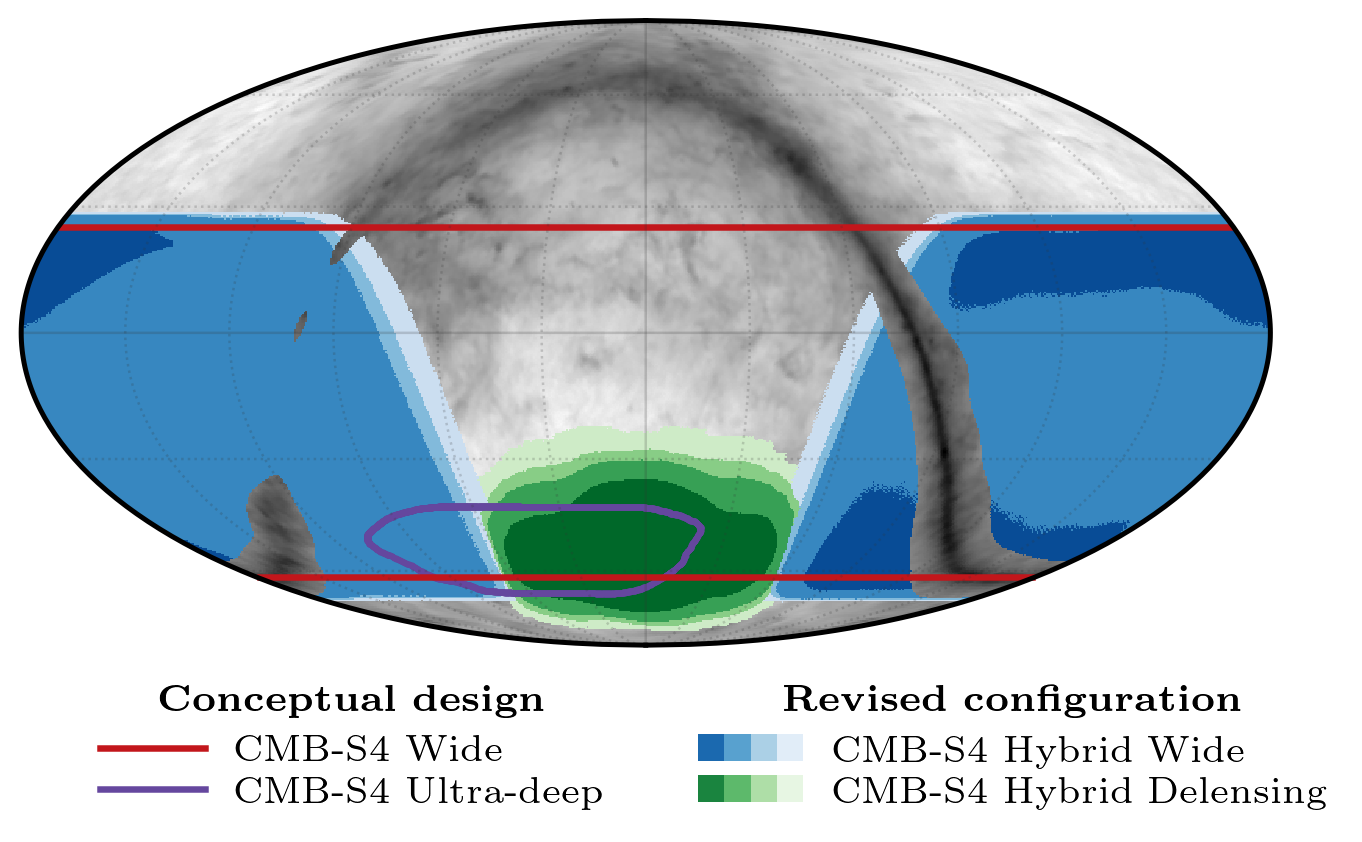

In [14]:
FIGURE2 = all_data['Figure 2']
dust_map = FIGURE2['dust map']
gal_mask = FIGURE2['revised footprint']['galactic mask']
revised_wide = FIGURE2['revised footprint']['wide']
revised_delensing = FIGURE2['revised footprint']['delensing']
pbd_wide = FIGURE2['pbd footprint']['wide']
pbd_deep = FIGURE2['pbd footprint']['ultra-deep']

min1, max1, cmap1 = 0.0, 4.5, plt.cm.Blues
min2, max2, cmap2 = 0.0, 4.5, plt.cm.Greens
pbd_wide_color = plt.cm.Reds(3.5 / 4.5) # 'C3'
pbd_deep_color = plt.cm.Purples(3.5 / 4.5) # 'C4'


fig = plt.figure()

# Dust map
hp.mollview(dust_map, norm='log', coord='GC', hold=True, cbar=False,
            cmap = plt.cm.binary, notext=True, title='')


# Revised configuration
wide_depths = sorted([val for val in set(revised_wide) if val != hp.UNSEEN], reverse=True)
delensing_depths = sorted([val for val in set(revised_delensing) if val != hp.UNSEEN], reverse=True)

revised_wide_remapped = np.full_like(revised_wide, hp.UNSEEN)
revised_delensing_remapped = np.full_like(revised_delensing, hp.UNSEEN)

for i, (wval, dval) in enumerate(zip(wide_depths, delensing_depths), start=1):
    revised_wide_remapped[revised_wide == wval] = i
    revised_delensing_remapped[revised_delensing == dval] = i

for i in range(1, 5):
    del_patch = np.where(revised_delensing_remapped == i, i, hp.UNSEEN)
    alpha2 = np.where((del_patch != hp.UNSEEN) & (gal_mask != 0), 1., 0.)
    hp.mollview(del_patch, alpha=alpha2, cbar=False, cmap=cmap2,
                min=min2, max=max2, reuse_axes=True, notext=True, title='')

    wide_patch = np.where(revised_wide_remapped == i, i, hp.UNSEEN)
    alpha1 = np.where((wide_patch != hp.UNSEEN) & (gal_mask != 0), 1., 0.)
    hp.mollview(wide_patch, alpha=alpha1, cbar=False, cmap=cmap1,
                min=min1, max=max1, reuse_axes=True, notext=True, title='')


# Preliminary baseline design
hp.projplot(pbd_deep['RA'], pbd_deep['DEC'], 'o', lonlat=True, color=pbd_deep_color, ms=1.2, mew=0, ls='none')

npts = 500
ra_dc0 = np.hstack([np.linspace(pbd_wide['RA'][0]+1, pbd_wide['RA'][1]-1, npts),
                    np.linspace(pbd_wide['RA'][0]+1, pbd_wide['RA'][1]-1, npts)])
dec_dc0 = np.hstack([np.linspace(pbd_wide['DEC'][1], pbd_wide['DEC'][1], npts),
                     np.linspace(pbd_wide['DEC'][0], pbd_wide['DEC'][0], npts)])
hp.projplot(ra_dc0, dec_dc0, lonlat=True, color=pbd_wide_color, ls='-')


# Graticules
hp.graticule(lw = 0.5, alpha = 0.2, color = '0.2')


# Legend
class ColormapHandler(mpl.legend_handler.HandlerBase):
    def __init__(self, cmap, vmin, vmax, npatches=4):
        self.cmap = cmap
        self.vmin = vmin
        self.vmax = vmax
        self.npatches = npatches
        super().__init__()

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        artists = []
        patch_width = width / self.npatches
        for i in range(self.npatches):
            val = (i + 1 - self.vmin) / (self.vmax - self.vmin)  # normalize to [0,1]
            color = self.cmap(val)
            rect = mpl.patches.FancyBboxPatch(
                (xdescent + i * patch_width, ydescent), patch_width, height,
                boxstyle="square,pad=0",
                facecolor=color, edgecolor='none', transform=trans
            )
            artists.append(rect)
        return artists

class ColumnTitleHandler(mpl.legend_handler.HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        rect = mpl.patches.Rectangle((0, 0), 0, 0, visible=False)
        return [rect]

title_left = mpl.patches.Patch(visible=False)
title_right = mpl.patches.Patch(visible=False)

line1_handle = plt.Line2D([], [], ls='-', color=pbd_wide_color)
line2_handle = plt.Line2D([], [], ls='-', color=pbd_deep_color)
wide_handle = mpl.patches.Patch()
del_handle = mpl.patches.Patch()

leg = plt.legend(handles=[title_left, line1_handle, line2_handle, title_right, wide_handle, del_handle],
                 labels=[r'\textbf{Conceptual design}', 'CMB-S4 Wide', 'CMB-S4 Ultra-deep',
                         r'\textbf{Revised configuration}', 'CMB-S4 Hybrid Wide', 'CMB-S4 Hybrid Delensing'],
                 handler_map={title_left:  ColumnTitleHandler(),
                              title_right: ColumnTitleHandler(),
                              wide_handle: ColormapHandler(cmap1.reversed(), min1, max1),
                              del_handle: ColormapHandler(cmap2.reversed(), min2, max2)},
                 loc='upper center', bbox_to_anchor=(0.555, -0.03),
                 ncols=2, handlelength=2.8, columnspacing=2)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()
texts = leg.get_texts()
handles = leg.legend_handles

left_x0 = min(handles[i].get_window_extent(renderer).x0 for i in [1, 2])
left_x1 = max(texts[i].get_window_extent(renderer).x1 for i in [1, 2])
right_x0 = min(handles[i].get_window_extent(renderer).x0 for i in [4, 5])
right_x1 = max(texts[i].get_window_extent(renderer).x1 for i in [4, 5])

for title_idx, center_x in [(0, (left_x0 + left_x1) / 2),
                             (3, (right_x0 + right_x1) / 2)]:
    t = texts[title_idx]
    bb = t.get_window_extent(renderer)
    center_y = (bb.y0 + bb.y1) / 2
    new_pos = fig.transFigure.inverted().transform((center_x, center_y))
    t.set_transform(fig.transFigure)
    t.set_position(new_pos)
    t.set_ha('center')


fig_name = 'footprints'
plt.savefig(f'figures/{fig_name}.pdf')

plt.show()
plt.close()

#subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

## Figure 3: Foregrounds

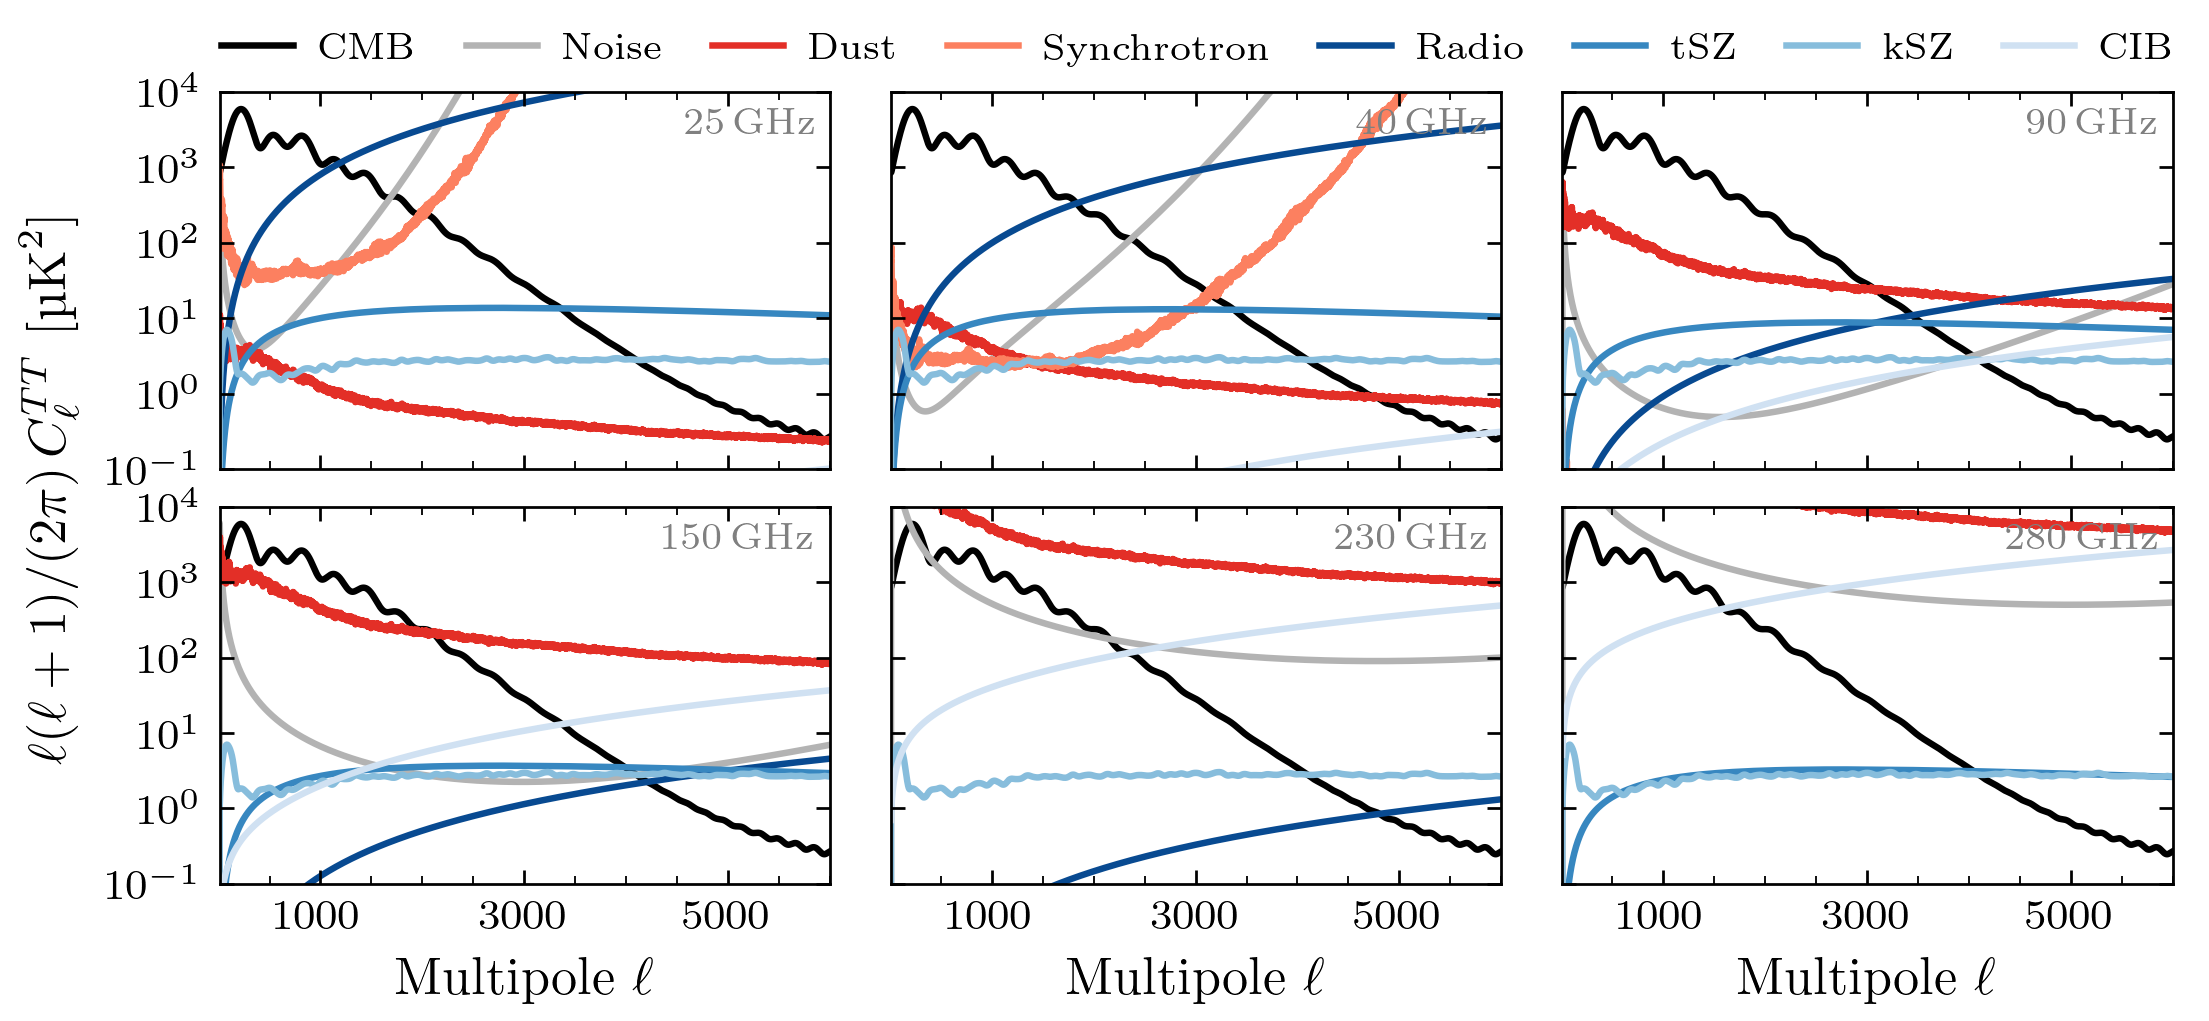

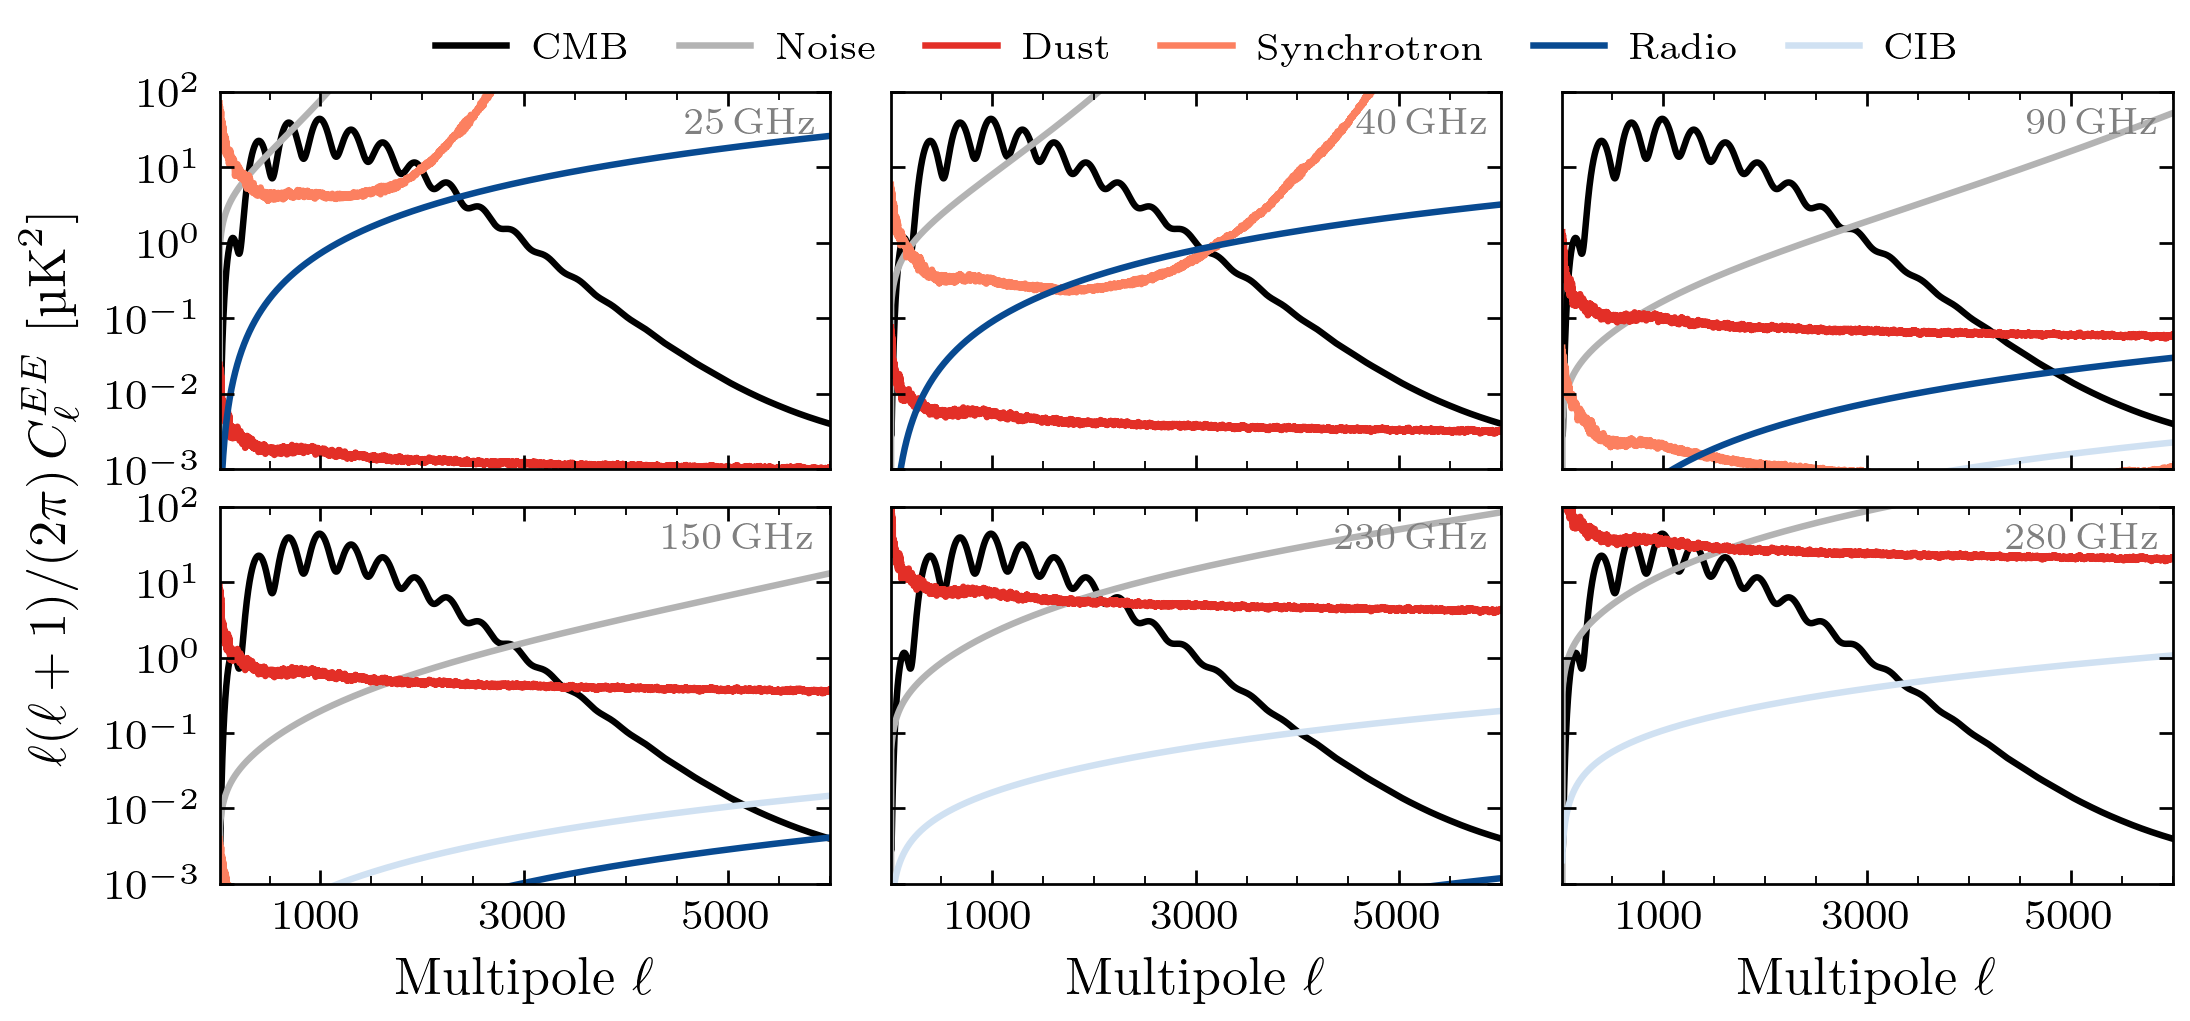

In [15]:
FIGURE3 = all_data['Figure 3']

lmax = 6000
xmin, xmax = 10, lmax
for spec in ['TT', 'EE']:
    fg_dict = FIGURE3[spec]

    if spec == 'TT':
        ymin, ymax = 1e-1, 1e4
        yticks = [1e-1, 1e-0, 1e1, 1e2, 1e3, 1e4]
        spec_name = 'tt'
        component_skip = []
        legend_anchor = (-0.04, 1.0)
    else:
        ymin, ymax = 1e-3, 1e2
        yticks = [1e-3, 1e-2, 1e-1, 1e-0, 1e1, 1e2]
        spec_name = 'ee'
        component_skip = ['tsz', 'ksz']
        legend_anchor = (0.31, 1.0)

    # Color map
    cmap_base = mpl.colormaps['Blues']
    cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Blues_sub',
                                                                 [cmap_base(i)
                                                                  for i in np.linspace(0.2, 0.9, 1000)])
    colors_blue = [cmap_subrange(i) for i in np.linspace(0, 1, 4)[::-1]]
    cmap_base = mpl.colormaps['Reds']
    cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Reds_sub',
                                                                 [cmap_base(i)
                                                                  for i in np.linspace(0.2, 0.9, 1000)])
    colors_red = [cmap_subrange(i) for i in np.linspace(0, 1, 4)[::-1]]
    component_dict_to_plot = {
        'cmb':     [r'CMB',      'black'],
        'noise':   ['Noise',     '0.7'],
        'galdust': [r'Dust',     colors_red[1]],
        'galsync': [r'Synchrotron', colors_red[2]],
        'radio':   [r'Radio',    colors_blue[0]],
        'tsz':     [r'tSZ',      colors_blue[1]],
        'ksz':     [r'kSZ',      colors_blue[2]],
        'cib':     [r'CIB',      colors_blue[3]],
    }
    
    
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{siunitx}'
    
     
    tr, tc = 2, 3
    plt.figure(figsize=(7., 7./2.45))
     
    for idx, nu in enumerate(fg_dict['noise']):
        rowval, colval = idx // tc, idx % tc
        ax = plt.subplot2grid((tr, tc), (rowval, colval), yscale='log')
    
        ax.set_xlim(xmin, xmax)
        ax.set_xticks([1000, 3000, 5000])
        ax.set_ylim(ymin, ymax)
        ax.set_yticks(yticks)
     
        # x-labels only on the bottom row, y-labels only on the left column
        if rowval == tr - 1:
            ax.set_xlabel(r'Multipole $\ell$')
        else:
            plt.setp(ax.get_xticklabels(), visible=False)
        if colval == 0:
            if rowval == 0:
                ax.set_ylabel(r'$\ell (\ell + 1) / (2\pi)\, C_\ell^{' + spec + r'}$ $[\si{\micro\kelvin\squared}]$') #, fontsize=fsval)
                ax.yaxis.set_label_coords(-0.23, -0.05)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        
        for component in component_dict_to_plot:
            if component in component_skip:
                continue
            curr_cl = fg_dict[component][nu]
            els = np.arange(len(curr_cl))
            dl_fac = els * (els + 1) / 2. / np.pi
            curr_dl = dl_fac * curr_cl
            labval, colorval = component_dict_to_plot[component]
            ax.plot(els, curr_dl, color=colorval, label=labval)
            
        ax.text(0.98, 0.96, r'\SI{%s}{GHz}' % (nu), transform=ax.transAxes, ha='right', va='top',
                color='0.5', fontsize=mpl.rcParams['legend.fontsize'])
        if idx == 0:
            ax.legend(bbox_to_anchor=(legend_anchor), loc='lower left', ncol=len(component_dict_to_plot),
                       columnspacing=1.28, handlelength=1.9, handletextpad=0.7)
    
    plt.subplots_adjust(hspace=0.1, wspace=0.1)

    fig_name = f'foregrounds_{spec_name}test'
    plt.savefig(f'figures/{fig_name}')
    
    plt.show()
    plt.close()
    
    subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

## Figure 4: ILC Residuals for Preliminary Baseline Design

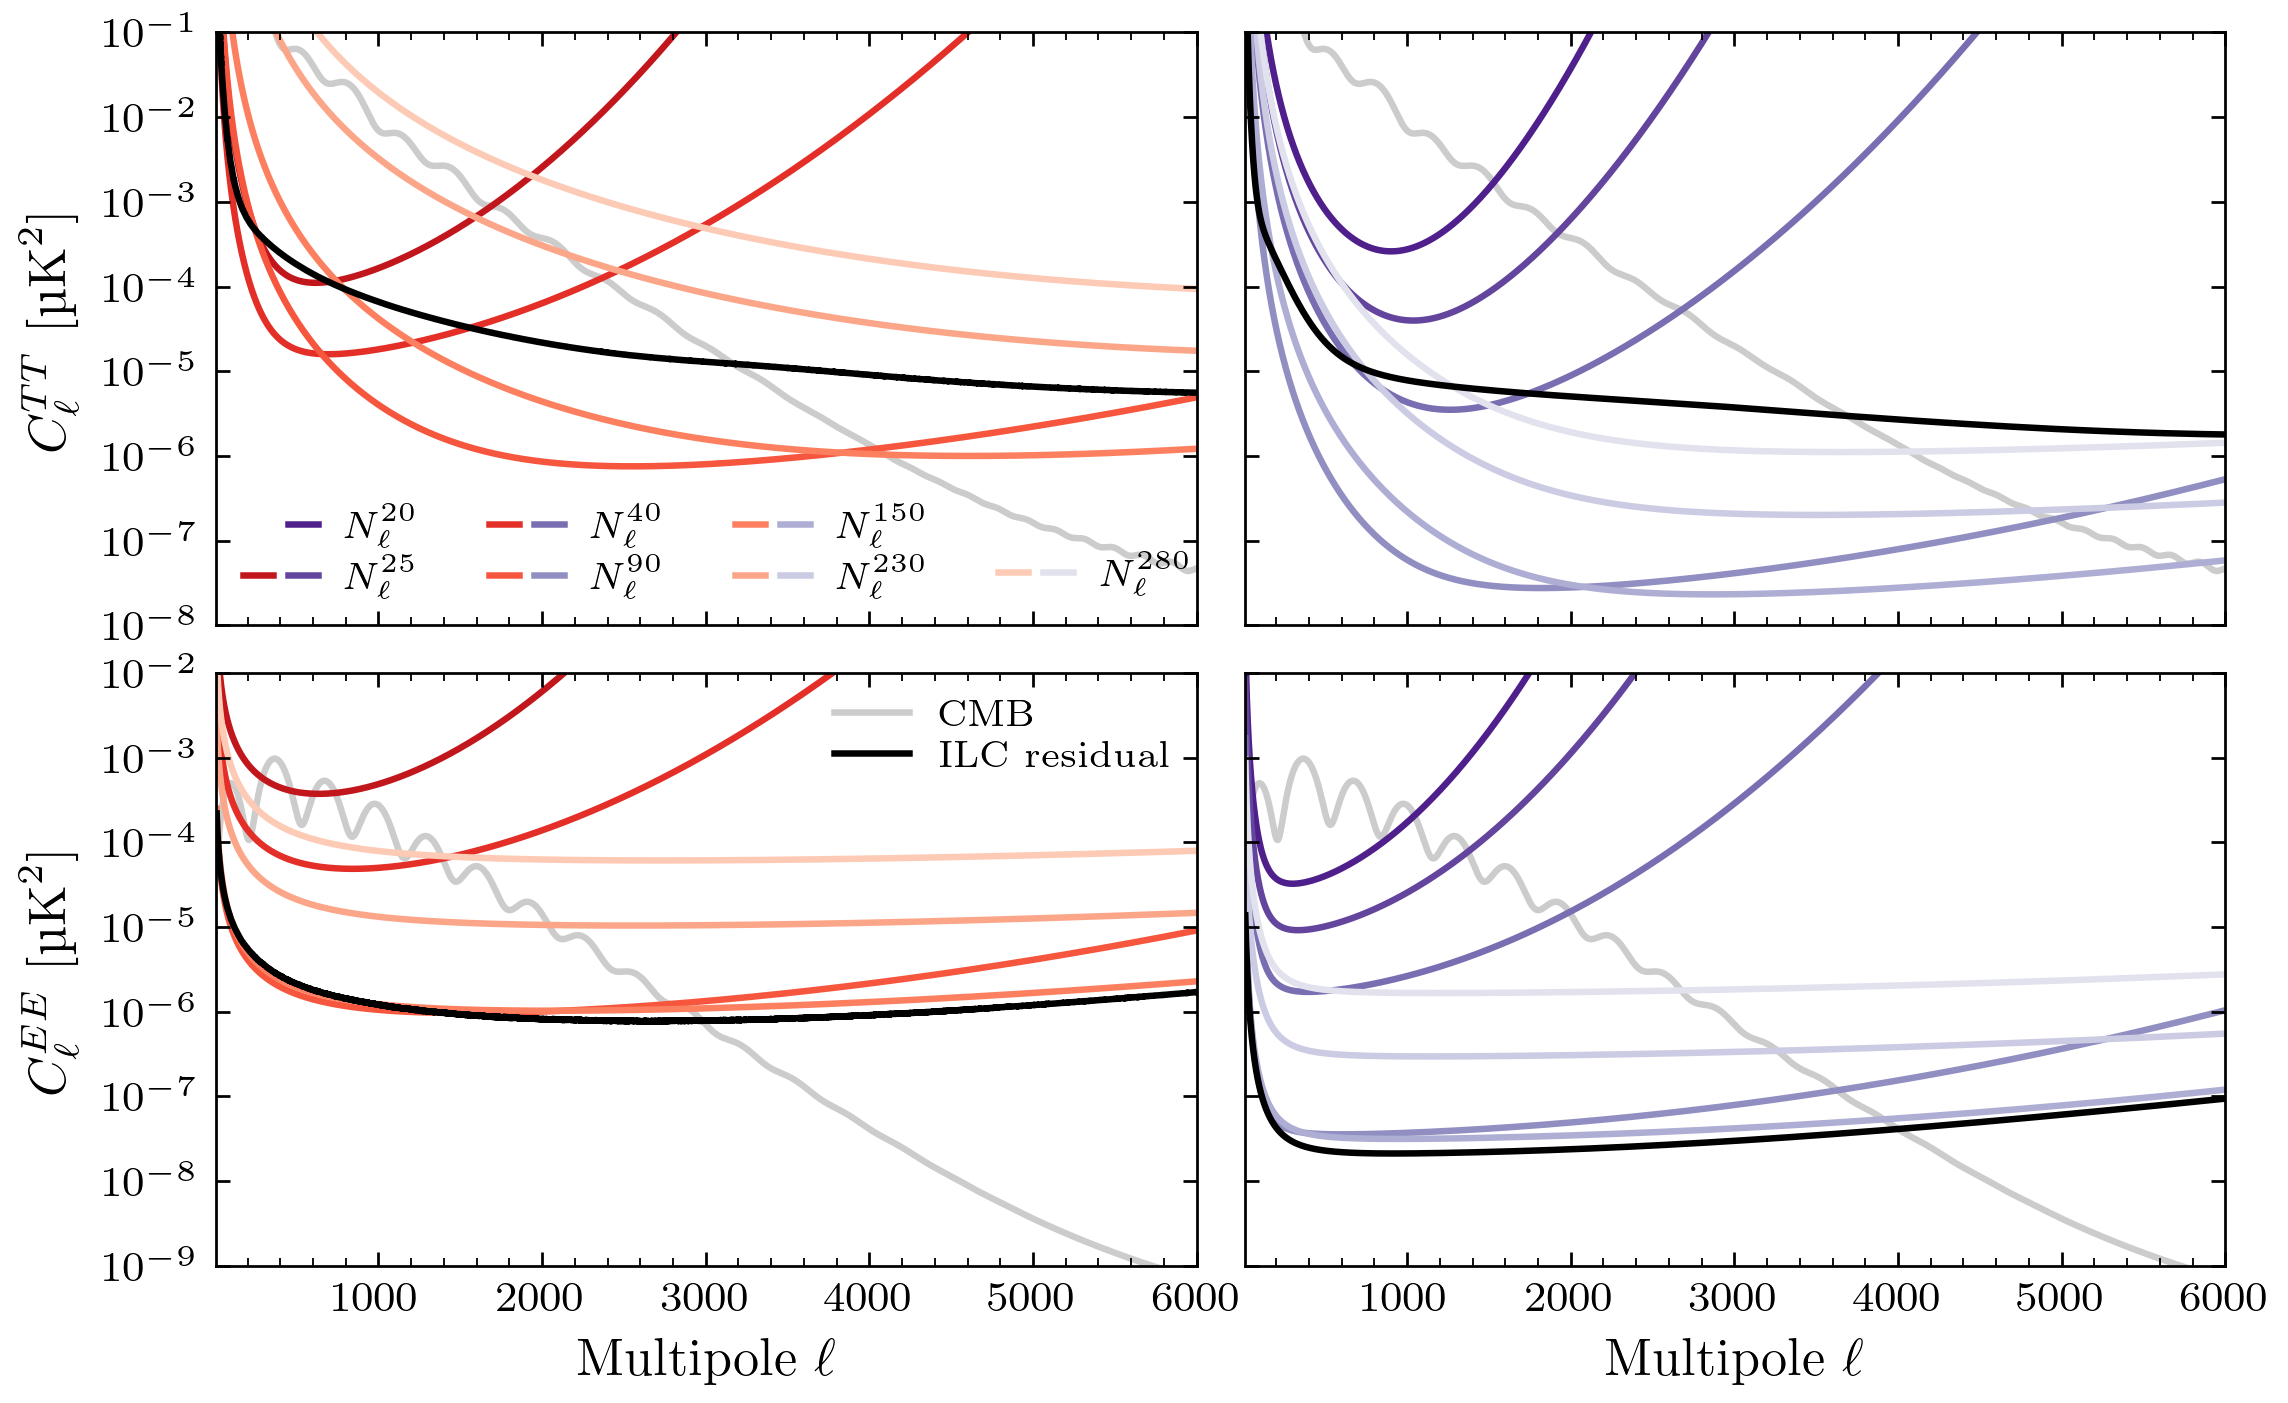

In [16]:
FIGURE4 = all_data['Figure 4']

freq_list = [20, 25, 40, 90, 150, 230, 280]
# Color map
colors = {}
cmap_base = mpl.colormaps['Reds']
cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Reds_sub',
                                                             [cmap_base(i)
                                                              for i in np.linspace(0.2, 0.9, 1000)])
colors['wide'] = [cmap_subrange(i) for i in np.linspace(0, 1, 7)[::-1]]
cmap_base = mpl.colormaps['Purples']
cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Purples_sub',
                                                             [cmap_base(i)
                                                              for i in np.linspace(0.2, 0.9, 1000)])
colors['deep'] = [cmap_subrange(i) for i in np.linspace(0, 1, 7)[::-1]]

comps_cmb = ['CMB', '0.8']
comps_ilc = ['ILC residual', 'black']
components_to_plot = {'wide': {'cmb': comps_cmb}, 'deep': {'cmb': comps_cmb}}
for num, freq in enumerate(freq_list):
    for survey in colors.keys():
        components_to_plot[survey]['nl_' + str(freq)] = [r'$N_\ell^{' + str(freq) + r'}$', colors[survey][num]]
del components_to_plot['wide']['nl_20']
components_to_plot['wide']['ilc'] = comps_ilc
components_to_plot['deep']['ilc'] = comps_ilc

spec_label = {'wide': 'CMB-S4 Wide survey', 'deep': 'CMB-S4 Ultra-deep survey'}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7.2, 7.2/GOLDEN_RATIO))

mpl.rcParams['text.latex.preamble'] = r'\usepackage{siunitx}'

line_list1 = {}
line_list2 = {}
for ncol, spec in enumerate(FIGURE4):
    if spec == 'TT':
        ymin, ymax = 1e-8, 1e-1
        yticks = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
        spec_name = 'tt'
    else:
        ymin, ymax = 1e-9, 1e-2
        yticks = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
        spec_name = 'ee'
        
    for nrow, survey in enumerate(FIGURE4[spec]):
        ax = axes[ncol, nrow]
        ax.set_xlim([10, 6000])
        ax.set_yscale('log')
        ax.set_ylim([ymin, ymax])
        ax.set_yticks(yticks)
        if nrow == 0:
            ax.set_ylabel(r'$C_\ell^{' + spec + r'}$ $[\si{\micro\kelvin\squared}]$', labelpad=5)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        if ncol == 0:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel(r'Multipole $\ell$')

        spectra = FIGURE4[spec][survey]
        line_list1[survey] = []
        line_list2[survey] = []
        for typ in components_to_plot[survey]:
            line, = ax.plot(spectra['ell'][11:], spectra[typ][11:], color=components_to_plot[survey][typ][1],
                            label=components_to_plot[survey][typ][0])
            if typ in ['cmb', 'ilc']:
                line_list1[survey].append(line)
            else:
                line_list2[survey].append(line)

        if ncol == 1:
            axes[0, nrow].text(0.02, 0.04, spec_label[survey], transform=ax.transAxes, ha='left', va='bottom',
                               color='0.5', fontsize=mpl.rcParams['legend.fontsize'])

empty = mpl.lines.Line2D([], [], color='none', label='')
line_list2['wide'].insert(0, empty)
legend2_list = [(line_list2['wide'][n], line_list2['deep'][n]) for n in range(len(line_list2['deep']))]
legend2_labels = [l.get_label() for l in line_list2['deep']]
legend2_list.insert(-1, (empty, empty))
legend2_labels.insert(-1, '')
axes[0, 0].legend(legend2_list, legend2_labels,
                  handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)},
                  loc='lower left', ncol=4, columnspacing=1.9, handletextpad=0.7)
axes[1, 0].legend(handles=line_list1['wide'], loc='upper right', ncol=1, columnspacing=1.9)
        
    
plt.subplots_adjust(hspace=0.08, wspace=0.08/GOLDEN_RATIO)

fig_name = f'residual_spectra2'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

## Figure 5: $\mathbf{N}_\mathbf{eff}$ Forecasts as Function of Time

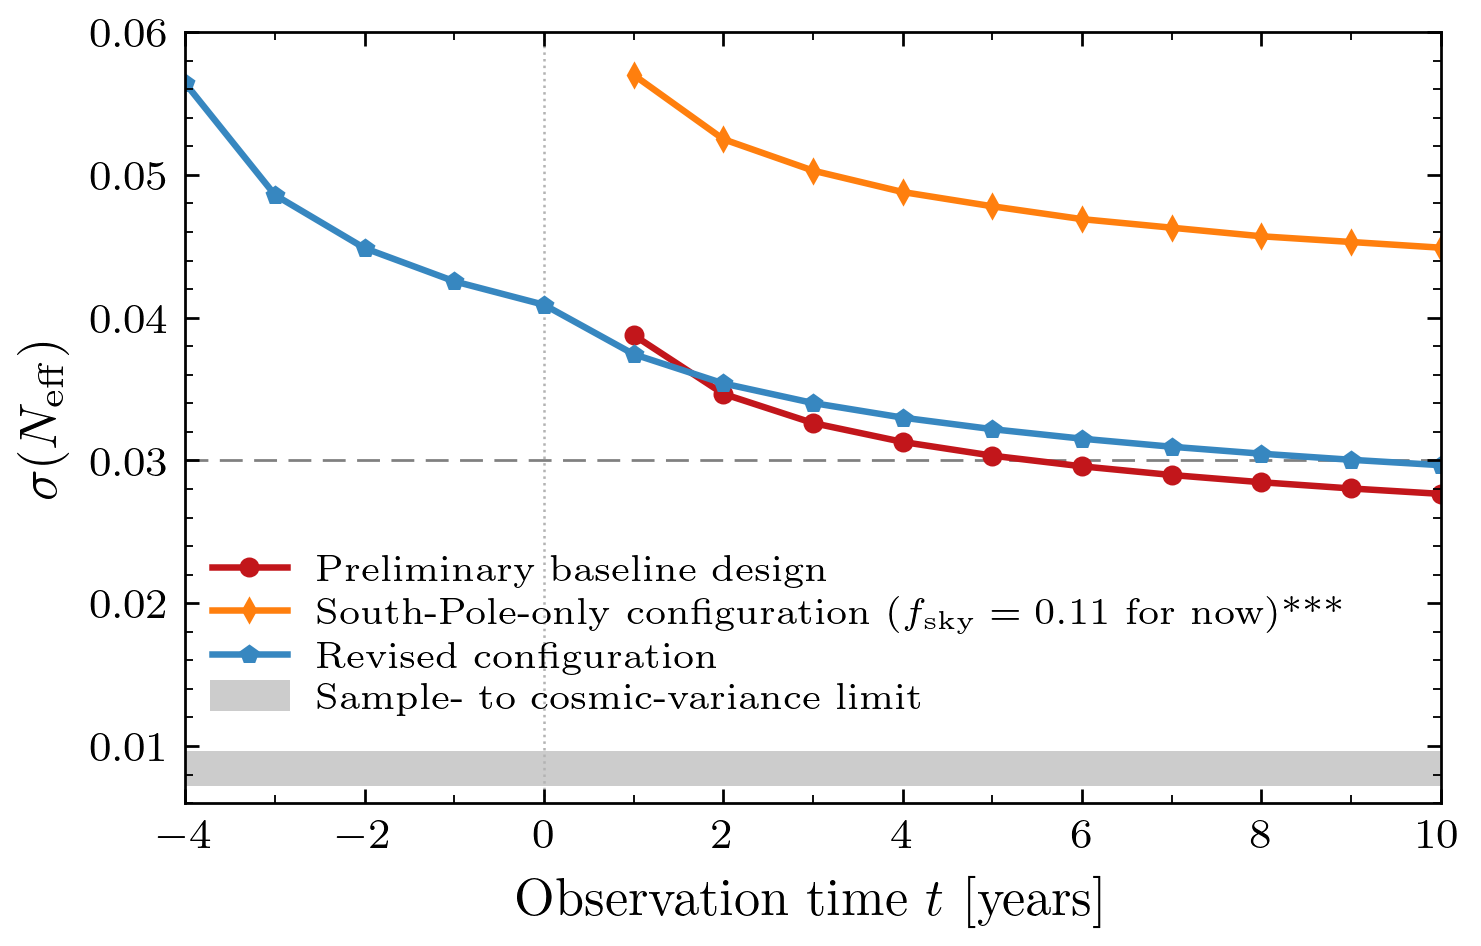

In [17]:
LONG_DASHES = (mpl.rcParams['lines.linewidth']*6.4, mpl.rcParams['lines.linewidth']*3.2)

FIGURE1 = all_data['Figure 1']
FIGURE5 = all_data['Figure 5']

plt.figure()

plt.xlabel(r'Observation time $t$ [years]')
plt.xlim([-4, 10])
plt.xticks(np.arange(-3, 10, 2), minor=True)
plt.ylabel(r'$\sigma(N_\mathrm{eff})$')
plt.ylim([0.006, 0.06])

plt.axvline(x=0, linestyle=':', color='0.7', linewidth=0.5)
plt.axhline(y=0.03, linestyle = '--', color='0.5', linewidth=0.55, dashes=LONG_DASHES)

plt.plot(FIGURE5['s4-pbd']['years'], FIGURE5['s4-pbd']['sigma_neff'], 'o-', markersize=3, color=plt.cm.Reds(3.5 / 4.5),
         label='Preliminary baseline design')
plt.plot(FIGURE5['s4-pole']['years'], FIGURE5['s4-pole']['sigma_neff'], 'd-', markersize=2.5, color='C1',
         label='South-Pole-only configuration ($f_\mathrm{sky} = 0.11$ for now)***')
plt.plot(FIGURE5['s4-revised']['years'], FIGURE5['s4-revised']['sigma_neff'], 'p-', markersize=3, color=plt.cm.Blues(3. / 4.5),
         label='Revised configuration')

plt.axhspan(FIGURE1['Constraints (2sigma)']['CVL']/2, FIGURE1['Constraints (2sigma)']['SVL']/2, color='0.8',
            label='Sample- to cosmic-variance limit')

plt.legend(loc='lower left', bbox_to_anchor=(0,0.08))

fig_name = 'neff_time_with-cvl_temporary'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

## Figure 6: Survey Design

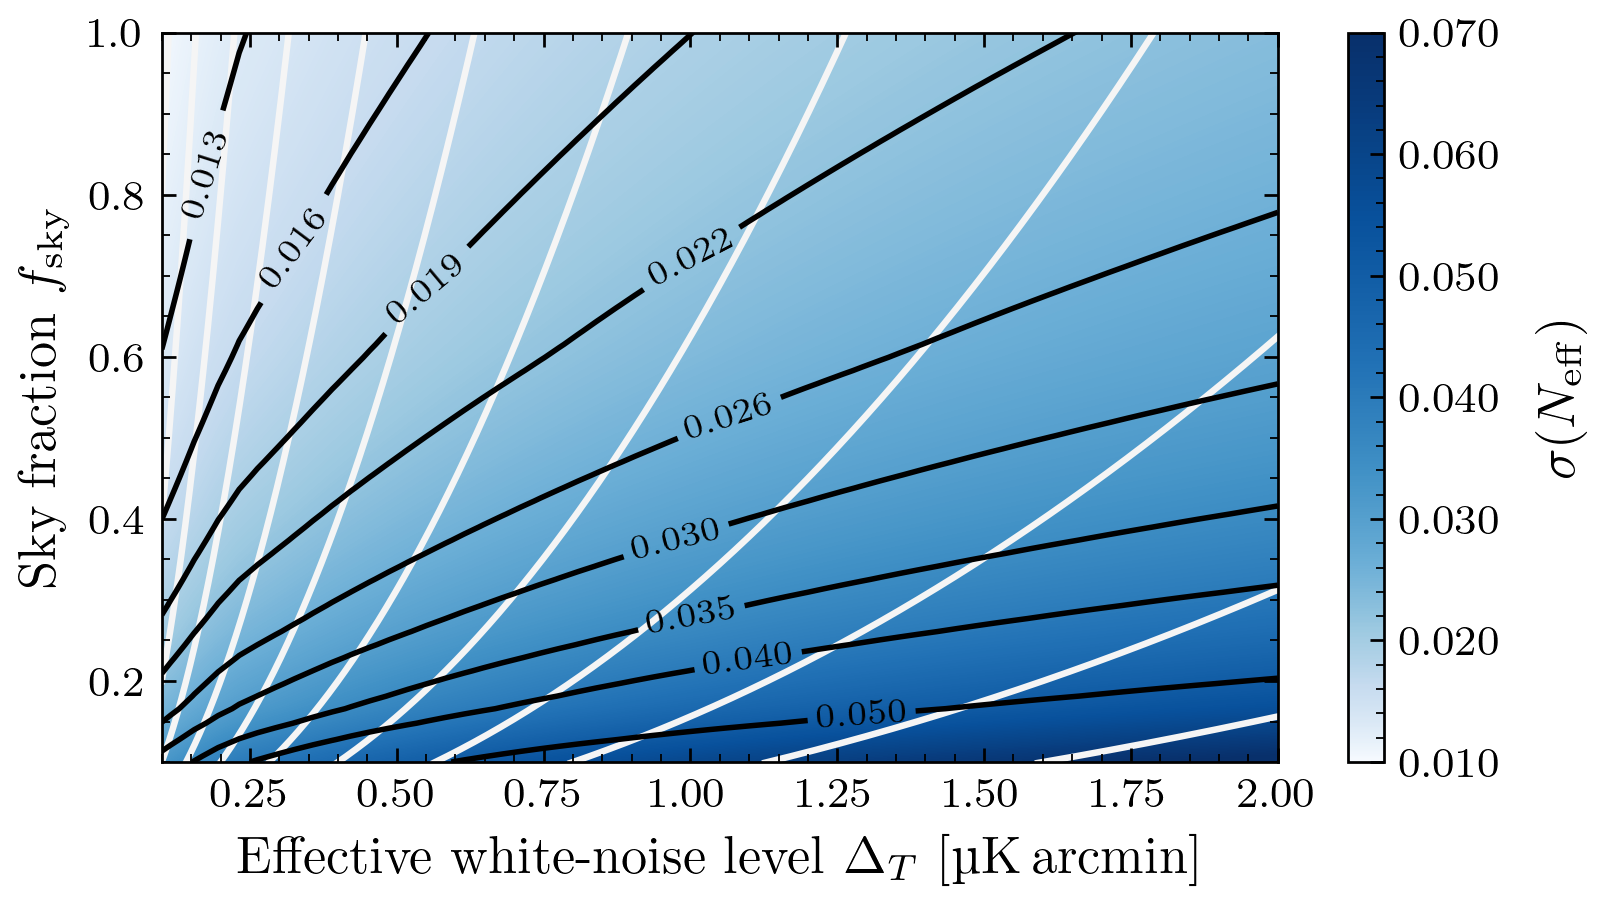

In [18]:
FIGURE6 = all_data['Figure 6']
noise_range, fsky_range, sigma_neff = FIGURE6['noise_range'], FIGURE6['fsky_range'], FIGURE6['sigma_neff']

plot_contours = np.array([0.013, 0.016, 0.019, 0.022, 0.026, 0.030, 0.035, 0.040, 0.050])
plot_contoursf = np.log10(np.arange(0.010, 0.0712, 0.0001))

def const_time_curve(noise, noise_ref, fsky_ref):
    return fsky_ref * (noise / noise_ref) ** 2


mpl.rcParams['text.latex.preamble'] = r'\usepackage{siunitx}'

plt.figure(figsize = (5., 5./1.9))

plt.xlabel(r'Effective white-noise level $\Delta_T$ $[\si{\micro\kelvin.arcmin}]$')
plt.xlim([0.1,2.])
plt.ylabel('Sky fraction $f_\mathrm{sky}$')
plt.ylim([0.1,1.])

contour = plt.contourf(sp_zoom(noise_range, 3, order=2), sp_zoom(fsky_range, 3, order=2),
                       np.log10(sp_zoom(np.transpose(sigma_neff), 3, order=2)),
                       plot_contoursf, cmap='Blues',
                       vmin=np.log10(0.01), vmax=np.log10(0.070))
contour.set_edgecolor("face")

for relative_time in 2.**np.arange(-3, 9, 1):
    noise_range2 = np.linspace(0.1, 2.0, int(10000/np.sqrt(relative_time)))
    fsky = const_time_curve(noise_range2, 0.1*np.sqrt(relative_time), 0.1)
    m = (fsky >= 0.099) & (fsky <= 1.002)
    plt.plot(noise_range2[m], fsky[m], color='0.96')

cp = plt.contour(sp_zoom(noise_range, 3, order=2), sp_zoom(fsky_range, 3, order=2),
                 sp_zoom(np.transpose(sigma_neff), 3, order=2), plot_contours, colors='black',
                 linewidths=mpl.rcParams['lines.linewidth']-0.2)
plt.clabel(cp, inline=True, fontsize=mpl.rcParams['xtick.labelsize']-1.5, inline_spacing=22)


fig = plt.gcf()
cbar = fig.colorbar(contour, pad=0.05)
cbar.ax.set_ylim(np.log10([0.01, 0.07]))
tick_loc = np.arange(0.01, 0.071, 0.01)
cbar.set_ticks(np.log10(tick_loc))
cbar.set_ticklabels(['{:1.3f}'.format(loc) for loc in tick_loc])
minor_loc = np.arange(0.010, 0.0701, 0.002)
cbar.ax.yaxis.set_minor_locator(mpl.ticker.FixedLocator(np.log10(minor_loc)))
cbar.set_label(r'$\sigma(N_\mathrm{eff})$', rotation='vertical', labelpad=12., verticalalignment='center')


fig_name = 'neff_noise-sky-time'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

## Figure 7: $\mathbf{N}_\mathbf{eff}$ Forecasts as Function of Maximum Multipole

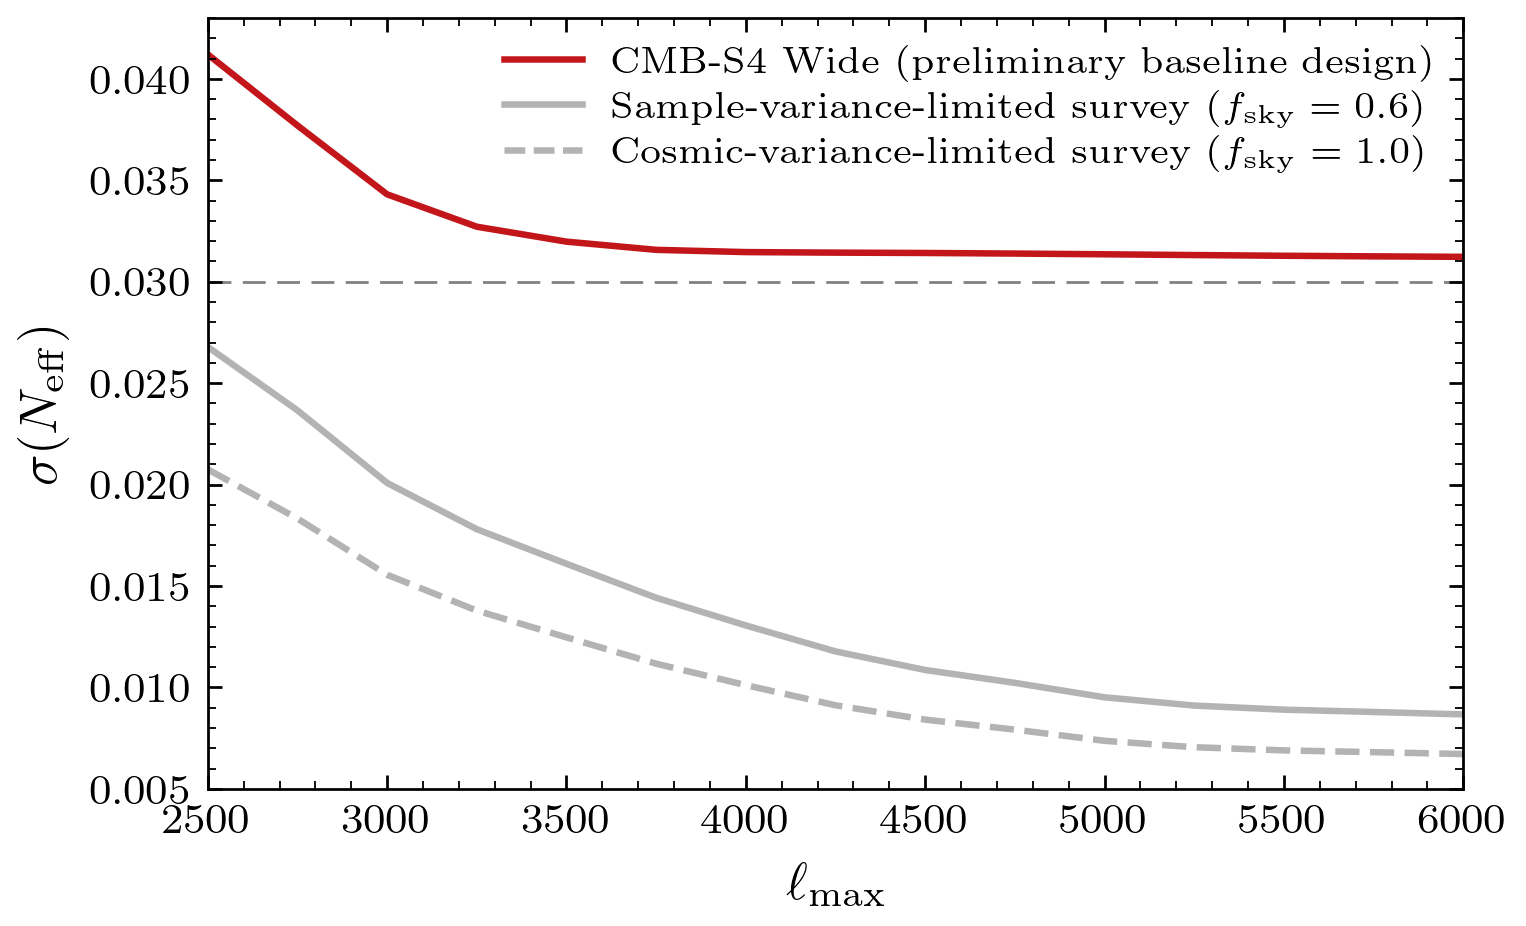

In [19]:
LONG_DASHES = (mpl.rcParams['lines.linewidth']*6.4, mpl.rcParams['lines.linewidth']*3.2)

FIGURE7 = all_data['Figure 7']

plt.figure()

plt.xlabel(r'$\ell_\mathrm{max}$')
plt.xlim([2500, 6000])
plt.ylabel(r'$\sigma(N_\mathrm{eff})$')
plt.ylim([0.005, 0.043])

plt.plot(FIGURE7['s4']['ell_max'], FIGURE7['s4']['sigma_neff'], color=plt.cm.Reds(3.5 / 4.5),
         label='CMB-S4 Wide (preliminary baseline design)')
plt.axhline(y=0.03, linestyle = '--', color='0.5', linewidth=0.55, dashes=LONG_DASHES)


plt.plot(FIGURE7['cvl']['ell_max'], FIGURE7['cvl']['sigma_neff']/np.sqrt(0.6), color='0.7',
         label='Sample-variance-limited survey ($f_\mathrm{sky} = 0.6$)')
plt.plot(FIGURE7['cvl']['ell_max'], FIGURE7['cvl']['sigma_neff'], '--', color='0.7',
         dashes=list(np.asarray(mpl.rcParams['lines.dashed_pattern'])*1.006))
plt.plot(np.nan, np.nan, '--', dashes=(3.2, 1.3), color='0.7',
         label='Cosmic-variance-limited survey ($f_\mathrm{sky} = 1.0$)')

plt.legend(loc='best', handlelength=2.08)

fig_name = 'neff_ellmax'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);